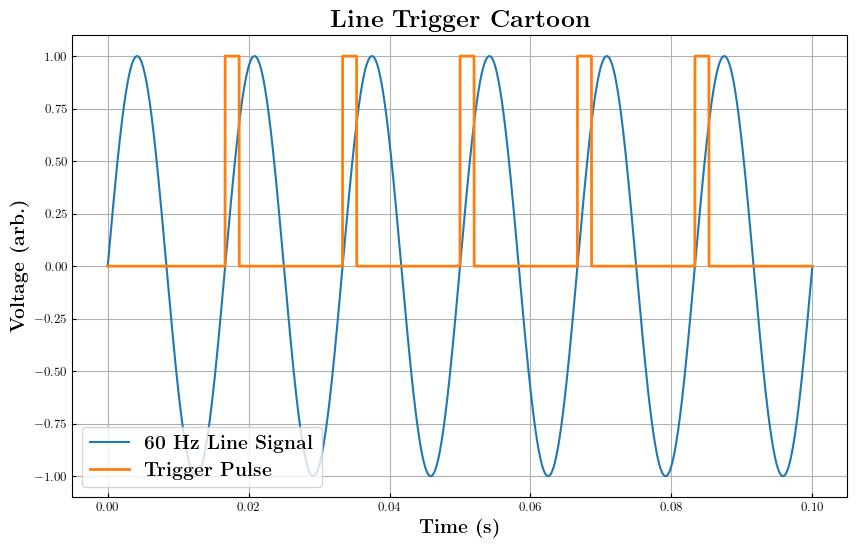

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams


rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Computer Modern']
rcParams['text.usetex'] = True
rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

fs = 100000         
duration = 0.1  
f_line = 60         
pulse_width = 0.002  


t = np.linspace(0, duration, int(fs * duration), endpoint=False)

line_signal = np.sin(2 * np.pi * f_line * t)


zero_crossings = np.where(
    (line_signal[:-1] < 0) & (line_signal[1:] >= 0)
)[0]


trigger = np.zeros_like(t)
pulse_samples = int(pulse_width * fs)

for idx in zero_crossings:
    trigger[idx:idx + pulse_samples] = 1


plt.figure(figsize=(10, 6))

plt.plot(t, line_signal, label=r"\textbf{60 Hz Line Signal}")
plt.plot(t, trigger, label=r"\textbf{Trigger Pulse}", linewidth=2)

plt.xlabel(r"\textbf{Time (s)}", fontsize = 14)
plt.ylabel(r"\textbf{Voltage (arb.)}", fontsize = 14)
plt.title(r"\textbf{Line Trigger Cartoon}", fontsize = 18)
plt.legend(fontsize = 14)
plt.grid(True)

plt.show()


In [3]:
import numpy as np
import io

def load_line_fit_parameters(filename):
    B0_fit = None
    B0_err = None
    harmonic_lines = []
    with open(filename, "r") as f:
        for line in f:
            stripped = line.strip()
            if not stripped or stripped.startswith("#"):
                continue
            if B0_fit is None:
                vals = np.fromstring(stripped, sep=" ")
                B0_fit, B0_err = vals[0], vals[1]
            else:
                harmonic_lines.append(stripped)
    harmonics = np.loadtxt(io.StringIO("\n".join(harmonic_lines)))
    if harmonics.ndim == 1:
        harmonics = harmonics[None, :]
    freqs = harmonics[:, 0]
    A_vals = harmonics[:, 1]
    A_errs = harmonics[:, 2]
    phi_vals = harmonics[:, 3]
    phi_errs = harmonics[:, 4]
    return B0_fit, B0_err, freqs, A_vals, A_errs, phi_vals, phi_errs

def _get_line_params(param_file, B0, A60, phi60, A180, phi180):
    if param_file is not None:
        B0_fit, B0_err, freqs, A_vals, A_errs, phi_vals, phi_errs = load_line_fit_parameters(param_file)
        return B0_fit, freqs, A_vals, phi_vals
    freqs = np.array([60.0, 180.0], dtype=float)
    A_vals = np.array([A60, A180], dtype=float)
    phi_vals = np.array([phi60, phi180], dtype=float)
    return B0, freqs, A_vals, phi_vals
# B0 = 0.3350, A60 = -0.3204, phi60 = 0.7425, A180 = -0.0978, phi180 = -0.5812,
def B_line_mG(t, B0 = 0.3350, A60 = -0.3204, phi60 = 0.7425, A180 = -0.0978, phi180 = -0.5812, param_file = 'Z:\Lab Data\Line_signal_fitted_params\line_signal_fit_params.txt'):
    B0_use, freqs, A_vals, phi_vals = _get_line_params(param_file, B0, A60, phi60, A180, phi180)
    t_arr = np.asarray(t, dtype=float)
    y = np.full_like(t_arr, B0_use, dtype=float)
    for f, A, phi in zip(freqs, A_vals, phi_vals):
        y = y + A * np.cos(2.0 * np.pi * f * t_arr + phi)
    return y

def B_rel_line_mG(t):
    return B_line_mG(t) - B_line_mG(0)

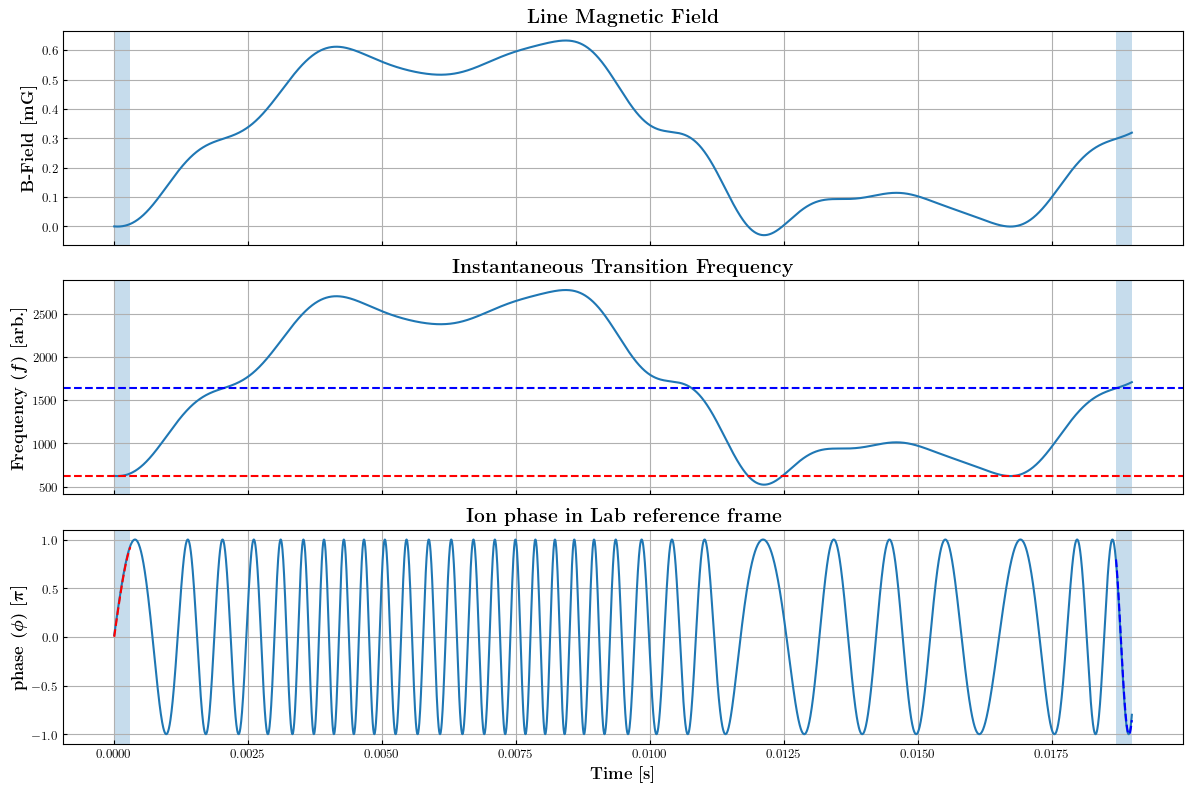

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
from matplotlib import rcParams

rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Computer Modern']
rcParams['text.usetex'] = True
rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

fs = 200000
duration = 19000e-6
f0 = 623.3
gamma = 3.4e3
pulse_width = 300e-6
t = np.linspace(0, duration, int(fs * duration), endpoint=False)

B_t = B_rel_line_mG(t)
# B_t = 0*np.linspace(0, duration, int(fs * duration), endpoint=False)

delta_t = gamma * B_t
f_inst = f0 + delta_t


phase = 2 * np.pi * np.cumsum(f_inst) / fs
signal = np.sin(phase)


pulse1_start = 0
pulse1_end = pulse_width

pulse2_start = duration - pulse_width
pulse2_end = duration

f_LO1 = f_inst[0]                 
f_LO2 = f0 + gamma*B_rel_line_mG(pulse2_start)##f_inst[-1]             

LO1 = np.zeros_like(t)
LO2 = np.zeros_like(t)
LO_dummy = np.zeros_like(t)
mask1 = (t >= pulse1_start) & (t <= pulse1_end)
mask2 = (t >= pulse2_start) & (t <= pulse2_end)
mask_dummy1 = (t >= pulse1_end) & (t <= pulse2_start)
mask_dummy2 = (t >= 0) & (t <= pulse2_start)

# LO1[mask1] = np.sin(2 * np.pi * f_LO1 * t[mask1] + 0)
# LO2[mask2] = np.sin(2 * np.pi * f_LO2 * t[mask2] + 0*2*np.pi*integrate.quad(B_rel_line_mG, 0, pulse2_start)[0]*gamma - 2*np.pi*(f_LO2 - f_LO1)*pulse2_start)#2*np.pi*(f_LO2 - f_LO1)*pulse2_start - 2*np.pi*f_LO2*pulse2_start)
# LO_dummy[mask_dummy] = np.sin(2 * np.pi * f_LO1 * t[mask_dummy] + 0)

LO1 = np.sin(2 * np.pi * f_LO1 * t[mask1] + 0)
LO2 = np.sin(2 * np.pi * f_LO2 * t[mask2] + 2*np.pi*integrate.quad(B_rel_line_mG, 0, pulse2_start)[0]*gamma - 1*2*np.pi*(f_LO2 - f_LO1)*pulse2_start)#2*np.pi*(f_LO2 - f_LO1)*pulse2_start - 2*np.pi*f_LO2*pulse2_start)
LO_dummy1 = np.sin(2 * np.pi * f_LO1 * t[mask_dummy1] + 0)
LO_dummy2 = np.sin(2 * np.pi * f_LO2 * t[mask_dummy2] + 0)

fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)


axs[0].plot(t, B_t)
axs[0].set_title(r"\textbf{Line Magnetic Field}", fontsize = 14)
axs[0].set_ylabel(r"\textbf{B-Field [mG]}", fontsize = 12)
axs[0].grid(True)

axs[1].plot(t, f_inst)
axs[1].axhline(f_LO1, linestyle='--', color = 'red')
axs[1].axhline(f_LO2, linestyle='--', color = 'blue')
axs[1].set_title(r"\textbf{Instantaneous Transition Frequency}", fontsize = 14)
axs[1].set_ylabel(r"\textbf{Frequency (\boldmath$f$) [arb.]}",  fontsize = 12)
axs[1].grid(True)

axs[2].plot(t, signal, label="Ion (Chirped)")
axs[2].plot(t[mask1], LO1, linestyle='--', label="LO @ first pulse", color = 'red')
axs[2].plot(t[mask2], LO2, linestyle='--', label="LO @ second pulse", color = 'blue')
# axs[2].plot(t[mask_dummy1], LO_dummy1, linestyle='--',  color = 'red', linewidth=0.75)
# axs[2].plot(t[mask_dummy2], LO_dummy2, linestyle='--',  color = 'blue', linewidth=0.75)
axs[2].set_title(r"\textbf{Ion phase in Lab reference frame}", fontsize = 14)
axs[2].set_xlabel(r"\textbf{Time [s]}", fontsize = 12)
axs[2].set_ylabel(r"\textbf{phase (\boldmath$\phi$) [\boldmath$\pi$]}", fontsize = 12)
axs[2].grid(True)
# axs[2].legend()


for ax in axs:
    ax.axvspan(pulse1_start, pulse1_end, alpha=0.25)
    ax.axvspan(pulse2_start, pulse2_end, alpha=0.25)

plt.tight_layout()
plt.show()


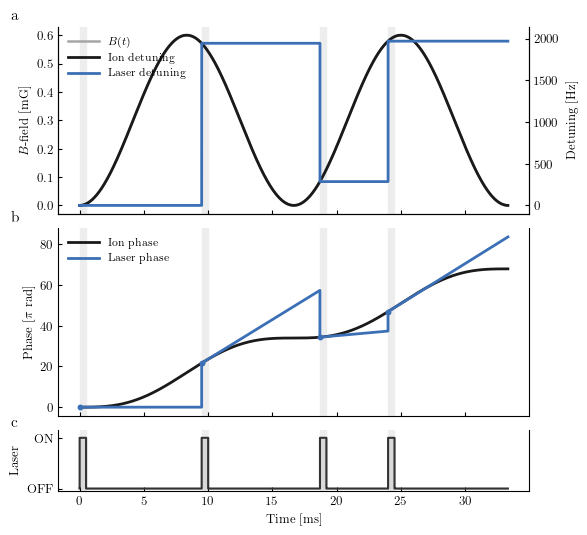

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid
from matplotlib import rcParams

rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath}",
    "font.size": 9,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


fs = 200000
duration = 33330e-6
f0 = 623.3
gamma = 3.4e3   # Hz / mG

pulse_times = np.array([
    0.01e-6,
    9500e-6,
    18700e-6,
    24000e-6,
], dtype=float)


pulse_width = 300e-6

pulse_width = np.array([500e-6, 500e-6, 500e-6, 500e-6], dtype=float)

first_update_index = 1

if np.isscalar(pulse_width):
    pulse_widths = np.full(len(pulse_times), pulse_width, dtype=float)
else:
    pulse_widths = np.asarray(pulse_width, dtype=float)
    if len(pulse_widths) != len(pulse_times):
        raise ValueError("pulse_width array must have the same length as pulse_times.")

pulse_ends = pulse_times + pulse_widths

if np.any(np.diff(pulse_times) < 0):
    raise ValueError("pulse_times must be sorted in increasing order.")

if np.any(pulse_ends > duration):
    raise ValueError("A pulse ends after the total sequence duration.")

t = np.linspace(0, duration, int(fs * duration), endpoint=False)
t_ms = 1e3 * t


B_t = B_rel_line_mG(t)          # [mG]
B_t = -0.3 * np.cos(2 * np.pi * 60 * t) + 0.3 
B_t = B_t - B_t[0]
delta_ion = gamma * B_t         # ion detuning [Hz]
phi_ion = 2 * np.pi * cumulative_trapezoid(delta_ion, t, initial=0)   # [rad]

delta_pulses = np.interp(pulse_times, t, delta_ion)
phi_pulses = np.interp(pulse_times, t, phi_ion)

laser_detuning = np.zeros_like(t)

for j in range(first_update_index, len(pulse_times)):
    t0 = pulse_times[j]
    t1 = pulse_times[j + 1] if j + 1 < len(pulse_times) else duration
    mask = (t >= t0) & (t < t1 if j + 1 < len(pulse_times) else t <= t1)
    laser_detuning[mask] = delta_pulses[j]

phase_t_plot = [0.0]
phase_laser_plot = [0.0]

current_t = 0.0
current_phi = 0.0
current_detuning = 0.0  

update_times = pulse_times[first_update_index:]

for k, t_update in enumerate(update_times):

    phi_before = current_phi + 2 * np.pi * current_detuning * (t_update - current_t)

    phase_t_plot.extend([t_update])
    phase_laser_plot.extend([phi_before])

    pulse_idx = first_update_index + k
    phi_snap = phi_pulses[pulse_idx]

    phase_t_plot.extend([t_update])
    phase_laser_plot.extend([phi_snap])

    current_t = t_update
    current_phi = phi_snap
    current_detuning = delta_pulses[pulse_idx]

phi_end = current_phi + 2 * np.pi * current_detuning * (duration - current_t)
phase_t_plot.extend([duration])
phase_laser_plot.extend([phi_end])

phase_t_plot = 1e3 * np.array(phase_t_plot)      # ms
phase_laser_plot = np.array(phase_laser_plot)    # rad

laser_on = np.zeros_like(t)
for t0, t1 in zip(pulse_times, pulse_ends):
    laser_on[(t >= t0) & (t < t1)] = 1

c_B = "0.65"
c_ion = "0.10"
c_laser = "#3B6FB6"


fig, axs = plt.subplots(
    3, 1,
    figsize=(6.2, 5.4),
    sharex=True,
    gridspec_kw={"height_ratios": [2.0, 2.0, 0.65]}
)

ax = axs[0]
ax_r = ax.twinx()

ax.plot(t_ms, B_t, color=c_B, lw=1.8, label=r"$B(t)$")
ax_r.plot(t_ms, delta_ion, color=c_ion, lw=2.0, label=r"Ion detuning")
ax_r.step(t_ms, laser_detuning, where="post", color=c_laser, lw=2.0, label=r"Laser detuning")

ax.set_ylabel(r"$B$-field [mG]")
ax_r.set_ylabel(r"Detuning [Hz]")

lines = ax.get_lines() + ax_r.get_lines()
labels = [line.get_label() for line in lines]
ax_r.legend(lines, labels, loc="upper left", frameon=False, fontsize=8, handlelength=2.8)

ax = axs[1]
ax.plot(t_ms, phi_ion / np.pi, color=c_ion, lw=2.0, label=r"Ion phase")
ax.plot(phase_t_plot, phase_laser_plot / np.pi, color=c_laser, lw=2.0, label=r"Laser phase")

ax.plot(1e3 * pulse_times, phi_pulses / np.pi, "o", color=c_laser, ms=3.2)

ax.set_ylabel(r"Phase [$\pi$ rad]")
ax.legend(loc="upper left", frameon=False, fontsize=8, handlelength=2.8)

ax = axs[2]
ax.step(t_ms, laser_on, where="post", color="0.2", lw=1.5)
ax.fill_between(t_ms, 0, laser_on, step="post", color="0.85")

ax.set_ylim(-0.05, 1.15)
ax.set_yticks([0, 1])
ax.set_yticklabels([r"OFF", r"ON"])
ax.set_ylabel(r"Laser")
ax.set_xlabel(r"Time [ms]")

for i, ax in enumerate(axs):
    for t0, t1 in zip(pulse_times, pulse_ends):
        ax.axvspan(1e3 * t0, 1e3 * t1, color="0.93", zorder=0)

    ax.spines["top"].set_visible(False)
    ax.text(
        -0.10, 1.02, chr(ord("a") + i),
        transform=ax.transAxes,
        fontsize=11,
        fontweight="bold",
        va="bottom"
    )

ax_r.spines["top"].set_visible(False)

plt.subplots_adjust(left=0.12, right=0.88, top=0.97, bottom=0.11, hspace=0.10)
plt.savefig("Line_signal_Compensation_Figure1_explanation.pdf")
plt.show()